In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os

# Task 1: Urn model for locust scenario

## A: Plotting the data for ∆L(L)

This code simulates swarm behavior in a locust urn model with 50 locusts moving in a unit circle. It measures the average change ΔL in the number of left-moving locusts as a function of L. It identifies equilibrium points where the swarm movement stabilizes.

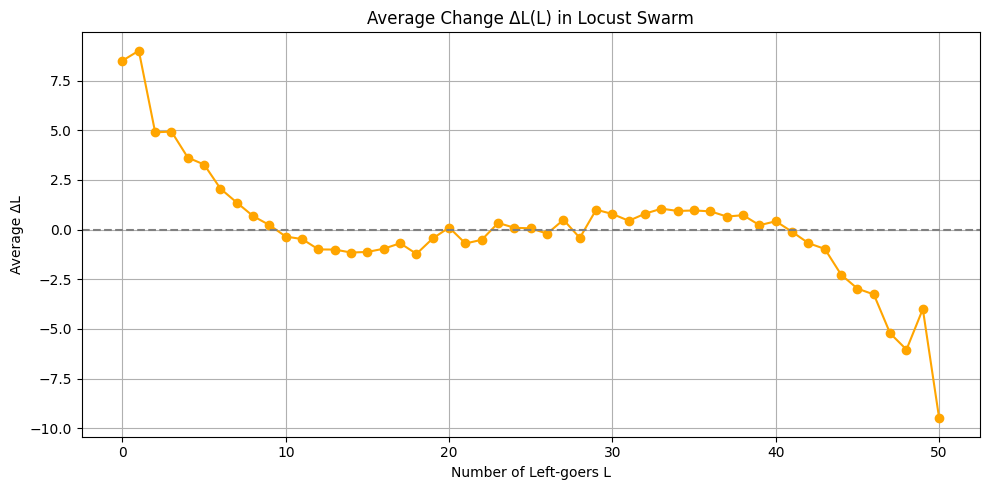

In [2]:
# Parameters
N = 50                   # swarm size
steps_warmup = 100       # stabilization phase
steps_measure = 20       # measurement phase
runs = 500               # simulation runs
speed = 0.01
r = 0.045
P = 0.15

# Sum and counts of delta L per L
delta_sum = np.zeros(N + 1)
count = np.zeros(N + 1)

for _ in range(runs):
    positions = np.random.rand(N)
    directions = np.random.choice([-1, 1], size=N)

    # Warm-up phase
    for _ in range(steps_warmup):
        for i in range(N):
            dists = np.abs(positions - positions[i])
            dists = np.minimum(dists, 1 - dists)
            neighbors = (dists < r) & (dists > 0)
            neighbor_dirs = directions[neighbors]
            if len(neighbor_dirs) > 0:
                if np.sum(neighbor_dirs == -directions[i]) > len(neighbor_dirs) / 2:
                    directions[i] = -directions[i]
                elif np.random.rand() < P:
                    directions[i] = -directions[i]
            elif np.random.rand() < P:
                directions[i] = -directions[i]
        positions = (positions + speed * directions) % 1

    # Measurement phase 
    for _ in range(steps_measure):
        L_prev = np.sum(directions == -1)

        for i in range(N):
            dists = np.abs(positions - positions[i])
            dists = np.minimum(dists, 1 - dists)
            neighbors = (dists < r) & (dists > 0)
            neighbor_dirs = directions[neighbors]
            if len(neighbor_dirs) > 0:
                if np.sum(neighbor_dirs == -directions[i]) > len(neighbor_dirs) / 2:
                    directions[i] = -directions[i]
                elif np.random.rand() < P:
                    directions[i] = -directions[i]
            elif np.random.rand() < P:
                directions[i] = -directions[i]

        positions = (positions + speed * directions) % 1
        L_new = np.sum(directions == -1)

        delta = L_new - L_prev
        delta_sum[L_prev] += delta
        count[L_prev] += 1

# Average delta L
with np.errstate(divide='ignore', invalid='ignore'):
    avg_delta = np.where(count > 0, delta_sum / count, 0)

# Plot
output_folder = "../../A5/output/task1"  
os.makedirs(output_folder, exist_ok=True)

plt.figure(figsize=(10, 5))
plt.plot(range(N + 1), avg_delta, marker='o', color='orange')
plt.axhline(0, color='gray', linestyle='--')
plt.title("Average Change ΔL(L) in Locust Swarm")
plt.xlabel("Number of Left-goers L")
plt.ylabel("Average ΔL")
plt.grid(True)
# Save the plot
filename = "task1a.png"
filepath = os.path.join(output_folder, filename)
plt.savefig(filepath)
plt.tight_layout()
plt.show()


The output plot shows the equilibrium points L*, where swarm direction stabilizes on average (ΔL(L∗) = 0).

Mathematically, 

ΔL(L∗) is the average change in no. of left going locusts and when ΔL(L∗)=0, it means that the these left goers do not change at that point. Thus, L* can be considered as the stabalizing point of the system.

## B: Fitting the model

The code fits the theoretical urn model to simulated locust swarm data. It estimates how the average change in the proportion of left-goers Δs(s) depends on swarm feedback intensity φ and a scaling constant c.


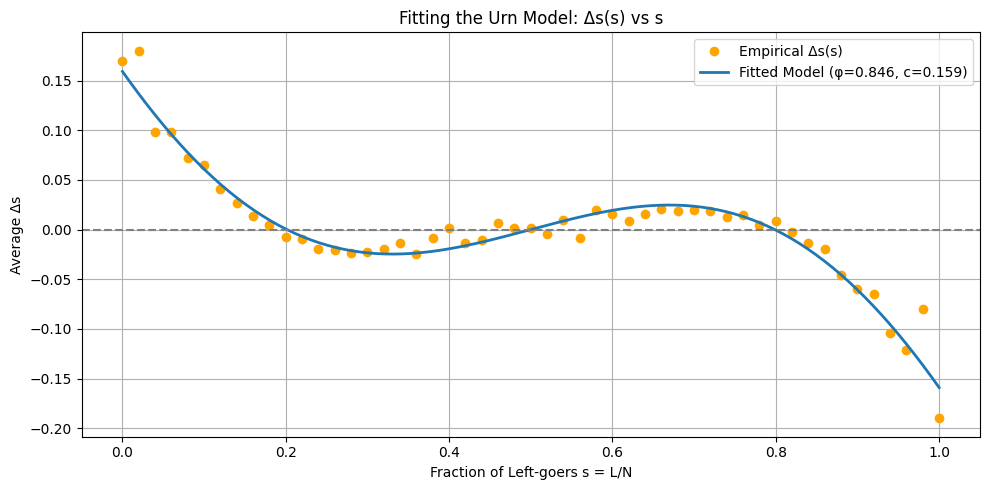

In [3]:
L_vals = np.arange(N + 1)
s_vals = L_vals / N
delta_s_empirical = avg_delta / N  # Δs = ΔL / N

def delta_s_model(s, phi, c):
    P_FB = phi * np.sin(np.pi * s)
    return 4 * c * (P_FB - 0.5) * (s - 0.5)

valid_indices = count > 0  
s_data = s_vals[valid_indices]
delta_s_data = delta_s_empirical[valid_indices]

popt, _ = curve_fit(delta_s_model, s_data, delta_s_data, bounds=([0, 0], [1, 10]))
phi_opt, c_opt = popt

s_fit = np.linspace(0, 1, 200)
delta_s_fit = delta_s_model(s_fit, phi_opt, c_opt)

# Plot
output_folder = "../../A5/output/task1"  
os.makedirs(output_folder, exist_ok=True)

plt.figure(figsize=(10, 5))
plt.plot(s_vals, delta_s_empirical, 'o', label='Empirical Δs(s)', color='orange')
plt.plot(s_fit, delta_s_fit, label=f'Fitted Model (φ={phi_opt:.3f}, c={c_opt:.3f})', linewidth=2)
plt.axhline(0, color='gray', linestyle='--')
plt.title("Fitting the Urn Model: Δs(s) vs s")
plt.xlabel("Fraction of Left-goers s = L/N")
plt.ylabel("Average Δs")
plt.legend()
plt.grid(True)
# Save the plot
filename = "task1b.png"
filepath = os.path.join(output_folder, filename)
plt.savefig(filepath)
plt.tight_layout()
plt.show()

In this output plot the orange dots represent the emperical data and the blue line represents the curve of fitted urn model. The x-axis shows the fraction of left-goers s=L/N, and the y-axis shows the average change Δs. The points where the curve crosses zero indicate swarm equilibrium states.

## C: Probability of positive feedback $P_{FB}$

It is the probability that a locust will switch direction due to local majority, influenced by:

s=L/N: current fraction of left-goers

φ: feedback strength (fitted in Part B)

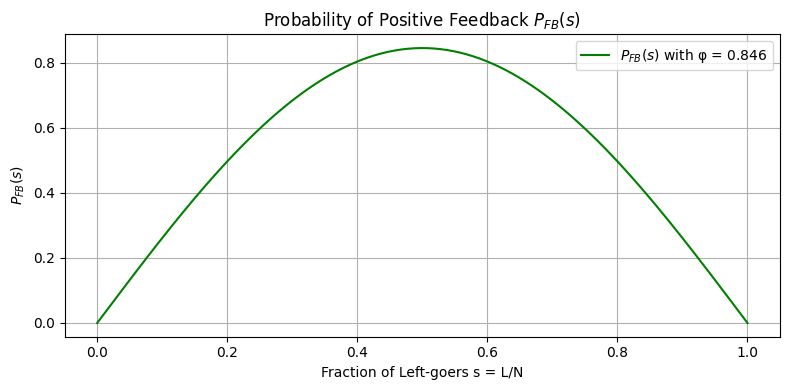

In [4]:
#  Plot probability of positive feedback P_FB(s) using fitted φ
s_vals_fb = np.linspace(0, 1, 200)
P_FB_vals = phi_opt * np.sin(np.pi * s_vals_fb)

# Plot
output_folder = "../../A5/output/task1"  
os.makedirs(output_folder, exist_ok=True)

plt.figure(figsize=(8, 4))
plt.plot(s_vals_fb, P_FB_vals, label=f'$P_{{FB}}(s)$ with φ = {phi_opt:.3f}', color='green')
plt.title("Probability of Positive Feedback $P_{FB}(s)$")
plt.xlabel("Fraction of Left-goers s = L/N")
plt.ylabel("$P_{FB}(s)$")
plt.grid(True)
# Save the plot
filename = "task1c.png"
filepath = os.path.join(output_folder, filename)
plt.savefig(filepath)
plt.legend()
plt.tight_layout()
plt.show()


### Results:  

1. The curve reaches its highest point at s = 0.5, showing that the swarm is most influenced by social feedback when it's evenly split. This happens when individuals are most likely to follow others.

2. At s = 0 and s = 1, the feedback drops to zero because everyone is already going the same way and there is no one left to convince. 

# Task 2: Density-dependent global switching

This objective of this task is to simulate swarm behavior for different swarm sizes N ∈ [20, 150]. For each swarm size, it runs the simulation for 5000+ steps and monitors global direction switches based on the number of left-goers (L).

In this case, the zones are defined as:
- Zone A: L > 0.7N (mostly left)
- Zone C: L < 0.3N (mostly right)
- Zone B: 0.3N ≤ L ≤ 0.7N (intermediate/transition)

When the swarm transitions from Zone A to B to C or from Zone C to B to A, a global switch is detected.

This code uses a state machine to track zone transitions, count valid switches, and compute the average time between switches.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
steps = 5000
speed = 0.01
r = 0.045
P = 0.15
N_values = np.arange(20, 151, 10)  
switch_durations = []
switch_counts = []

# Detect which zone based on L
def get_zone(L, N):
    if L > 0.7 * N:
        return 'A'
    elif L < 0.3 * N:
        return 'C'
    else:
        return 'B'

# Main simulation loop
for N in N_values:
    durations = []
    positions = np.random.rand(N)
    directions = np.random.choice([-1, 1], size=N)
    
    zone = get_zone(np.sum(directions == -1), N)
    prev_outer_zone = None
    timer = 0

    for _ in range(steps):
        # Update directions based on neighbor majority
        new_directions = directions.copy()
        for i in range(N):
            dists = np.abs(positions - positions[i])
            dists = np.minimum(dists, 1 - dists)
            neighbors = (dists < r) & (dists > 0)
            neighbor_dirs = directions[neighbors]
            if len(neighbor_dirs) > 0:
                if np.sum(neighbor_dirs == -directions[i]) > len(neighbor_dirs) / 2:
                    new_directions[i] = -directions[i]
                elif np.random.rand() < P:
                    new_directions[i] = -directions[i]
            elif np.random.rand() < P:
                new_directions[i] = -directions[i]
        directions = new_directions
        positions = (positions + speed * directions) % 1
        
        # Zone logic
        L = np.sum(directions == -1)
        current_zone = get_zone(L, N)

        if current_zone in ['A', 'C']:
            if prev_outer_zone and prev_outer_zone != current_zone:
                durations.append(timer)
            timer = 0
            prev_outer_zone = current_zone
        elif current_zone == 'B':
            timer += 1

    switch_durations.append(np.mean(durations) if durations else 0)
    switch_counts.append(len(durations))


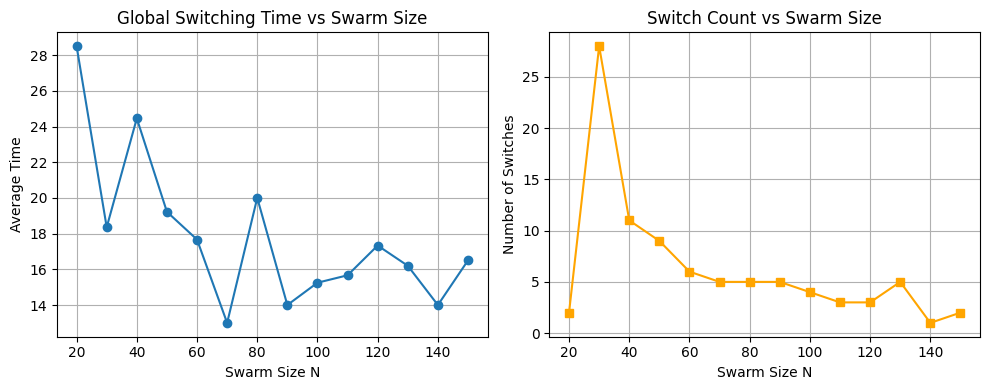

In [6]:
# Plot average time between switches
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(N_values, switch_durations, marker='o', label='Avg. Time Between Switches')
plt.xlabel("Swarm Size N")
plt.ylabel("Average Time")
plt.title("Global Switching Time vs Swarm Size")
plt.grid(True)

# Plot number of switches
plt.subplot(1, 2, 2)
plt.plot(N_values, switch_counts, marker='s', color='orange', label='Number of Switches')
plt.xlabel("Swarm Size N")
plt.ylabel("Number of Switches")
plt.title("Switch Count vs Swarm Size")
plt.grid(True)

plt.tight_layout()
plt.show()


### Output:

1. The plot shows that smaller swarms have higher and more variable switching times due to noise, while larger swarms stabilize quickly and switch less often—indicating increased coordination with density.

2. The number of switches decreasses with swarm size N. This means. that there is more switching in smaller swarms, making the model more sensitive to noise.
